## Overall Structure
We begin by creating a population matrix for each ethnicity and gender combination, where:

Each row represents a unique agent (individual).

Each column represents a calendar year.

The time span is divided into two :

Retrospective years (1990–2023) for historical analysis.

Projection years (2024–2050) for future forecasting.

and therefore we will have two set of matrices, for this file, we only show matrices of retrospective years `age_matrix_vec`

The values in the matrix represent the age of each agent in a given year:

A value of -1 indicates that the agent is either not yet born or has already died in that year.


## Disease Mapping
Once the population matrix is established, we perform matrix mapping using disease-specific transition rates to simulate health outcomes. This results in corresponding disease state matrices.

Examples:
Diabetes Matrices `diabetes_mat_list`

Values:

0 = Healthy

0.5 = Pre-diabetes

1 = Diabetes

Hypertension Matrices `hyper_mat_list`

Values:

0 = Healthy

1 = Hypertension



In this case, that we don't use struct but use matrix directly. 

Through it may be hard to read and understand, but it's faster for the matrix operations. 

In [1]:
from impute_bmi import calculate_bmi,apply_bmi,bmitable

Shape of bmitable: (8, 16)


In [ ]:
# bmi_samples_dict = {}

# for group in range(N):
#     bmi_samples_dict[group] = {}
#     for key, value in age_dict[group].items():
#         age = key
#         age_vector = np.arange(18, key + 1)
#         year_born = 1990 - key 
#         # Repeat the BMI calculation for 'value' times
#         bmi_samples = np.array([calculate_bmi(age_vector, year_born, group, bmitable, height=170.0) for _ in range(value)])
#         bmi_samples_dict[group][age] = bmi_samples

In [ ]:
# # Create directory if it doesn't exist
# import os
# save_dir = "../future_data/bmi_samples"
# os.makedirs(save_dir, exist_ok=True)

# for group in range(N):
#     for key, value in bmi_samples_dict[group].items():
#         save_path = os.path.join(save_dir, f"bmi_samples_group{group}_age{key}.npy")
#         np.save(save_path, value)

# get 1990 - 2023 population as well

In [ ]:
# num_files = 8  # Change this to the actual number of files to read

# age_matrix_vec_2023 = []

# path = "/Users/haolong/Documents/demos_v_matrix/output/"
# for i in range(num_files):
#     # Create the filename dynamically

#     filename = f"popu_matrix_{i}.csv"
#     matrix = pd.read_csv(path + filename).to_numpy() # convert to numpy
#     age_matrix_vec_2023.append(matrix)

# for idx in range(8):
#     matrix = age_matrix_vec_2023[idx]  # Extract the matrix
#     # Check each row, and keep it if not all values are negative
#     filtered_matrix = matrix[~np.all(matrix < 0, axis=1)]
#     age_matrix_vec_2023[idx] = filtered_matrix



In [33]:
from Age_BMI_loading import age_matrix_vec_2050
age_matrix_vec = age_matrix_vec_2050

### create albuminuria matrices from 1990 - 2050 

In [3]:
# Fix the IndexError by ensuring age_mat is converted to integer type for array indexing

age_matrix_vec

# Convert all age matrices to integer type to fix IndexError
for i in range(len(age_matrix_vec)):
    age_matrix_vec[i] = age_matrix_vec[i].astype(int)
    print(f"age_matrix_vec[{i}] data type after conversion: {age_matrix_vec[i].dtype}")

age_matrix_vec[0] data type after conversion: int64
age_matrix_vec[1] data type after conversion: int64
age_matrix_vec[2] data type after conversion: int64
age_matrix_vec[3] data type after conversion: int64
age_matrix_vec[4] data type after conversion: int64
age_matrix_vec[5] data type after conversion: int64
age_matrix_vec[6] data type after conversion: int64
age_matrix_vec[7] data type after conversion: int64


# get plot 

In [4]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd




In [5]:
# Load the saved matrices and check their sizes
albu_mat_storage = []
for i in range(8):
    filename = f'../future_data_1990_2050/albu_matrix_forecast/albu_mat_group_{i}.npy'
    loaded_array = np.load(filename) 
    albu_mat_storage.append(loaded_array)
    print(f"Loaded group {i} array from {filename}, shape: {loaded_array.shape}")

Loaded group 0 array from ../future_data_1990_2050/albu_matrix_forecast/albu_mat_group_0.npy, shape: (5, 10, 103903, 61)
Loaded group 1 array from ../future_data_1990_2050/albu_matrix_forecast/albu_mat_group_1.npy, shape: (5, 10, 108964, 61)
Loaded group 2 array from ../future_data_1990_2050/albu_matrix_forecast/albu_mat_group_2.npy, shape: (5, 10, 21074, 61)
Loaded group 3 array from ../future_data_1990_2050/albu_matrix_forecast/albu_mat_group_3.npy, shape: (5, 10, 20487, 61)
Loaded group 4 array from ../future_data_1990_2050/albu_matrix_forecast/albu_mat_group_4.npy, shape: (5, 10, 14978, 61)
Loaded group 5 array from ../future_data_1990_2050/albu_matrix_forecast/albu_mat_group_5.npy, shape: (5, 10, 13353, 61)
Loaded group 6 array from ../future_data_1990_2050/albu_matrix_forecast/albu_mat_group_6.npy, shape: (5, 10, 5789, 61)
Loaded group 7 array from ../future_data_1990_2050/albu_matrix_forecast/albu_mat_group_7.npy, shape: (5, 10, 7024, 61)


In [6]:
from prevalence import get_prevalence,get_pre_prevalence,get_overall_prevalence,get_overall_pre_prevalence

In [ ]:
# # Create lists to store matrices for simulations
# albu_mat_list = []

# # For each simulation (t) and group (k), extract prevalence data
# for k in range(0, 8):  # 8 groups based on the loaded data
#     for t in range(0, 5):  # 5 simulations
#         age_matrix_vec_sample = [matrix[k,:,:] for matrix in age_matrix_vec]
#         albu_mat_list_sim = []
        
#         # Extract matrices for this simulation
#         for matrix in albu_mat_storage:
#             # Extract the t-th simulation slice (matrix[t,:,:])
#             matrix_2d = matrix[t,k, :, :]
#             albu_mat_list_sim.append(matrix_2d)

#         pre_albu_mat_list = []

#         # Calculate prevalence for each time point
#         for time_k in range(-61, 0):    
#             overall_prevalence = get_overall_prevalence(age_matrix_vec_sample, albu_mat_list_sim, time_k)   
#             pre_albu_mat_list.append(overall_prevalence)
        
#         # Store the prevalence data for this simulation
#         albu_mat_list.append(pre_albu_mat_list)

In [ ]:
# Create lists to store matrices for simulations
# pre_albu_mat_list = []

# # For each simulation (t) and group (k), extract pre-prevalence data
# for k in range(0, 8):  # 8 groups based on the loaded data
#     for t in range(0, 5):  # 5 simulations
#         age_matrix_vec_sample = [matrix[k,:,:] for matrix in age_matrix_vec]
#         albu_mat_list_sim = []
        
#         # Extract matrices for this simulation
#         for matrix in albu_mat_storage:
#             # Extract the t-th simulation slice (matrix[t,:,:])
#             matrix_2d = matrix[t,k, :, :]
#             albu_mat_list_sim.append(matrix_2d)

#         sim_pre_albu_mat_list = []

#         # Calculate pre-prevalence for each time point
#         for time_k in range(-61, 0):    
#             overall_pre_prevalence = get_overall_pre_prevalence(age_matrix_vec_sample, albu_mat_list_sim, time_k)   
#             sim_pre_albu_mat_list.append(overall_pre_prevalence)
        
#         # Store the pre-prevalence data for this simulation
#         pre_albu_mat_list.append(sim_pre_albu_mat_list)

In [326]:


# Convert to DataFrame for easier handling
import pandas as pd
albu_prevalence_df = pd.DataFrame(albu_mat_list).T  # Transpose so rows are time points, columns are simulations

# Calculate 95% CI and mean
albu_prevalence_mean = albu_prevalence_df.mean(axis=1)
albu_prevalence_std = albu_prevalence_df.std(axis=1)
albu_prevalence_ci_lower = albu_prevalence_df.quantile(0.025, axis=1)
albu_prevalence_ci_upper = albu_prevalence_df.quantile(0.975, axis=1)







In [327]:

# Convert pre_albu_mat_list to DataFrame for easier handling
pre_albu_prevalence_df = pd.DataFrame(pre_albu_mat_list).T  # Transpose so rows are time points, columns are simulations

# Calculate 95% CI and mean for pre-prevalence
pre_albu_prevalence_mean = pre_albu_prevalence_df.mean(axis=1)
pre_albu_prevalence_std = pre_albu_prevalence_df.std(axis=1)
pre_albu_prevalence_ci_lower = pre_albu_prevalence_df.quantile(0.025, axis=1)
pre_albu_prevalence_ci_upper = pre_albu_prevalence_df.quantile(0.975, axis=1)

In [328]:
# Calculate year 2021 prevalence (index 31 since 1990 + 31 = 2021)
year_2021_index = 31
prevalence_2021_mean = albu_prevalence_mean.iloc[year_2021_index]
prevalence_2021_lower = albu_prevalence_ci_lower.iloc[year_2021_index]
prevalence_2021_upper = albu_prevalence_ci_upper.iloc[year_2021_index]

# Calculate 2021 pre-prevalence as well
pre_prevalence_2021_mean = pre_albu_prevalence_mean.iloc[year_2021_index]
pre_prevalence_2021_lower = pre_albu_prevalence_ci_lower.iloc[year_2021_index]
pre_prevalence_2021_upper = pre_albu_prevalence_ci_upper.iloc[year_2021_index]


In [315]:
pre_prevalence_2021_lower

0.0

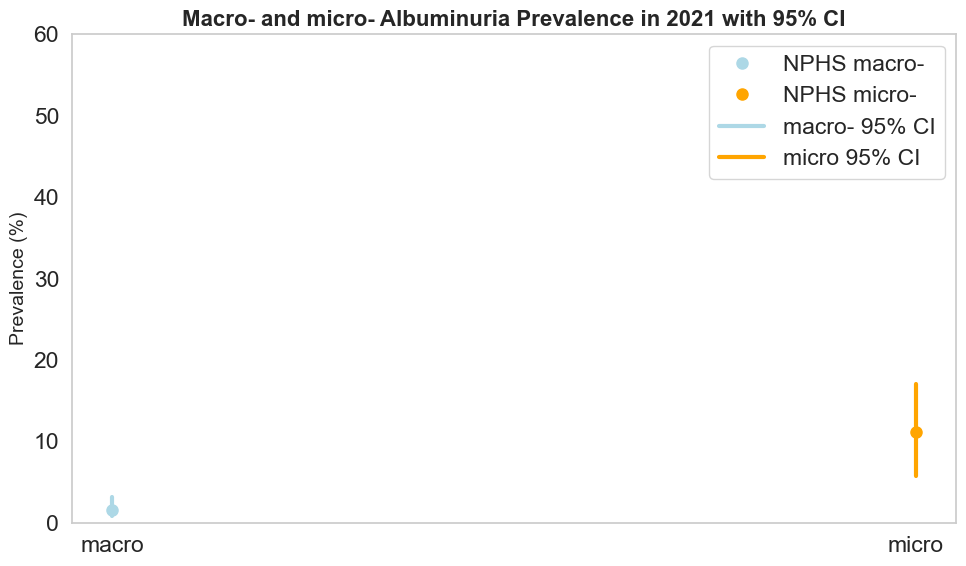

In [339]:
# Create combined line plot for 2021 prevalence with CI
plt.figure(figsize=(10, 6))

x_positions = [0.35, 0.65]
categories = ['macro', 'micro']
means = [1.6,11.1]

# Plot the means as points individually to avoid color list issue
plt.plot(x_positions[0], means[0], 'o', markersize=8, color='lightblue', label='NPHS macro-')
plt.plot(x_positions[1], means[1], 'o', markersize=8, color='orange', label='NPHS micro-')

# Plot vertical lines for confidence intervals
plt.plot([x_positions[0], x_positions[0]], 
         [prevalence_2021_lower * 100, prevalence_2021_upper * 100], 
         color='lightblue', linewidth=3, label='macro- 95% CI')

plt.plot([x_positions[1], x_positions[1]], 
         [pre_prevalence_2021_lower * 100, pre_prevalence_2021_upper * 100], 
         color='orange', linewidth=3, label='micro 95% CI')

plt.title('Macro- and micro- Albuminuria Prevalence in 2021 with 95% CI', 
          fontsize=16, fontweight='bold')
plt.ylabel('Prevalence (%)', fontsize=14)
plt.xticks(x_positions, categories)
plt.ylim(0, 60)
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.savefig('plots/albu_prevalence_2021_ci_combined.png')
plt.show()

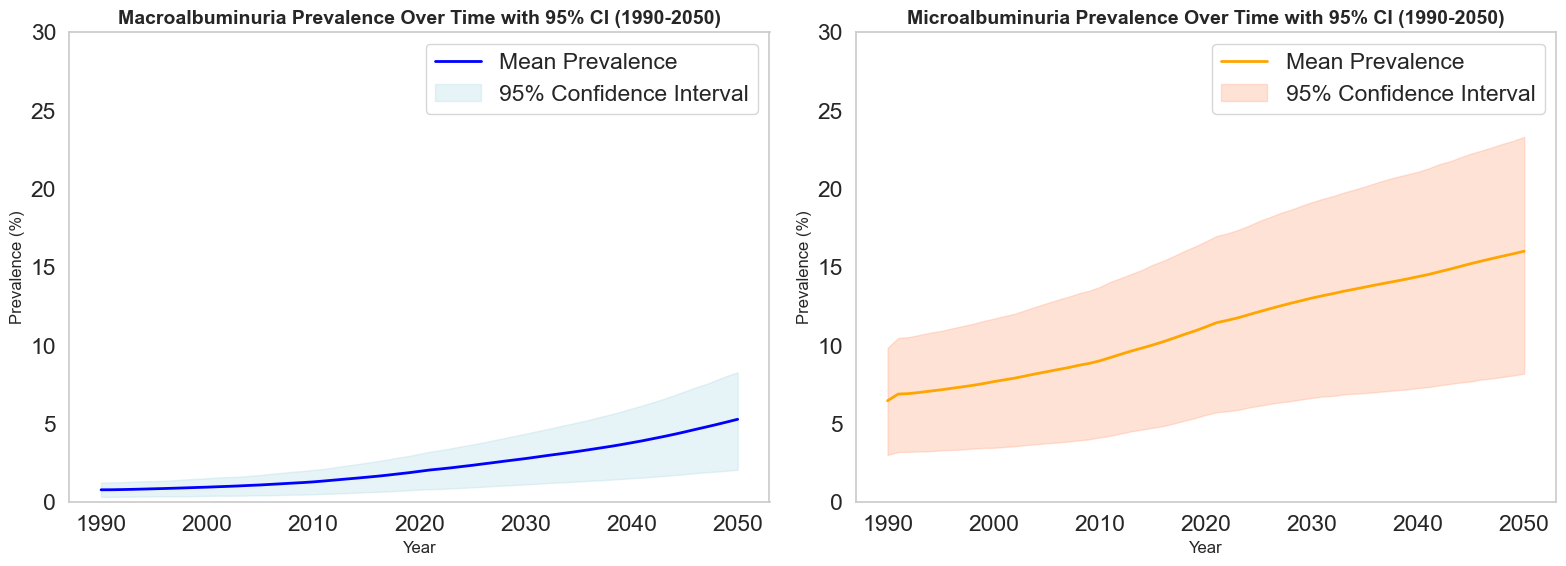

Macroalbuminuria mean prevalence in 1990: 0.008
Macroalbuminuria mean prevalence in 2050: 0.053
Microalbuminuria mean prevalence in 1990: 0.065
Microalbuminuria mean prevalence in 2050: 0.160
DataFrame shape: (61, 40)


In [342]:
# Create years array for plotting
years = list(range(1990, 2051))

# Create panel plot with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: Macroalbuminuria prevalence
ax1.plot(years, albu_prevalence_mean * 100, linewidth=2, color='blue', label='Mean Prevalence')
ax1.fill_between(years, albu_prevalence_ci_lower * 100, albu_prevalence_ci_upper * 100, 
                 alpha=0.3, color='lightblue', label='95% Confidence Interval')
ax1.set_title('Macroalbuminuria Prevalence Over Time with 95% CI (1990-2050)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Prevalence (%)', fontsize=12)
ax1.set_ylim(0, 30)
ax1.legend()
ax1.grid(False)

# Right panel: Microalbuminuria prevalence
ax2.plot(years, pre_albu_prevalence_mean * 100, linewidth=2, color='orange', label='Mean Prevalence')
ax2.fill_between(years, pre_albu_prevalence_ci_lower * 100, pre_albu_prevalence_ci_upper * 100, 
                 alpha=0.3, color='lightsalmon', label='95% Confidence Interval')
ax2.set_title('Microalbuminuria Prevalence Over Time with 95% CI (1990-2050)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Prevalence (%)', fontsize=12)
ax2.set_ylim(0, 30)
ax2.legend()
ax2.grid(False)

plt.tight_layout()
plt.savefig('plots/albu_prevalence_over_time_panel.png')
plt.show()

print(f"Macroalbuminuria mean prevalence in 1990: {albu_prevalence_mean.iloc[0]:.3f}")
print(f"Macroalbuminuria mean prevalence in 2050: {albu_prevalence_mean.iloc[-1]:.3f}")
print(f"Microalbuminuria mean prevalence in 1990: {pre_albu_prevalence_mean.iloc[0]:.3f}")
print(f"Microalbuminuria mean prevalence in 2050: {pre_albu_prevalence_mean.iloc[-1]:.3f}")
print(f"DataFrame shape: {albu_prevalence_df.shape}")

## get new BMI values 

In [7]:
from impute_bmi import apply_bmi

In [8]:
parent_dir = "../future_data_1990_2050/bmi_matrix"

In [9]:
# Load BMI matrices
bmi_matrix_ls = []
for idx in range(8):
    file_path = os.path.join(parent_dir, f"bmi_matrix_{idx}.npy")
    try:
        bmi_matrix = np.load(file_path)
        bmi_matrix_ls.append(bmi_matrix)
        print(f"Loaded: {file_path} with shape {bmi_matrix.shape}")
    except FileNotFoundError:
        print(f"Warning: File not found: {file_path}")
        # Handle missing file case - could create empty matrix or skip
        continue


Loaded: ../future_data_1990_2050/bmi_matrix/bmi_matrix_0.npy with shape (10, 103903, 61)
Loaded: ../future_data_1990_2050/bmi_matrix/bmi_matrix_1.npy with shape (10, 108964, 61)
Loaded: ../future_data_1990_2050/bmi_matrix/bmi_matrix_2.npy with shape (10, 21074, 61)
Loaded: ../future_data_1990_2050/bmi_matrix/bmi_matrix_3.npy with shape (10, 20487, 61)
Loaded: ../future_data_1990_2050/bmi_matrix/bmi_matrix_4.npy with shape (10, 14978, 61)
Loaded: ../future_data_1990_2050/bmi_matrix/bmi_matrix_5.npy with shape (10, 13353, 61)
Loaded: ../future_data_1990_2050/bmi_matrix/bmi_matrix_6.npy with shape (10, 5789, 61)
Loaded: ../future_data_1990_2050/bmi_matrix/bmi_matrix_7.npy with shape (10, 7024, 61)


In [10]:
from Age_BMI_loading import (
    bmi_samples_dict,
)

In [11]:
bmi_samples_dict[0][18].shape

(922, 1)

## get diabetes 

In [23]:
diabetes_mat_list[0].shape

(10, 103903, 61)

In [24]:
# Check unique values in diabetes_mat_list
print("Unique values in each diabetes matrix:")
for i, diabetes_mat in enumerate(diabetes_mat_list):
    unique_vals = np.unique(diabetes_mat)
    print(f"Group {i}: {unique_vals}")
    
# Also check the overall unique values across all matrices
all_unique_vals = np.unique(np.concatenate([mat.flatten() for mat in diabetes_mat_list]))
print(f"\nOverall unique values across all diabetes matrices: {all_unique_vals}")


Unique values in each diabetes matrix:
Group 0: [0.  0.5 1. ]
Group 1: [0.  0.5 1. ]
Group 2: [0.  0.5 1. ]
Group 3: [0.  0.5 1. ]
Group 4: [0.  0.5 1. ]
Group 5: [0.  0.5 1. ]
Group 6: [0.  0.5 1. ]
Group 7: [0.  0.5 1. ]

Overall unique values across all diabetes matrices: [0.  0.5 1. ]


In [30]:
age_matrix_vec[0].shape

(10, 103903, 61)

In [43]:
# test 0.14287226908551864
get_overall_prevalence_3d(age_matrix_vec, diabetes_mat_list, -28)

0.08899402543335565

In [406]:
# Calculate diabetes prevalence for each simulation and each year from -61 to 0
import pandas as pd
import matplotlib.pyplot as plt

# Initialize list to store results
results_data = []

# Loop through each simulation
for sim in range(11):
    age_matrix_vec_sample = []
    diabetes_mat_list_sample = []
    
    # Collect data for this simulation across all groups
    for i in range(8):
        age_matrix_vec_sample.append(age_matrix_vec[i][sim, :])
        diabetes_mat_list_sample.append(diabetes_mat_list[i][sim, :])
    
    # Calculate prevalence for each year from -61 to 0 (corresponding to 1990-2050)
    for time_idx in range(-60, 1):  # -61 to 0 inclusive
        year = 2050 + time_idx  # Convert time index to actual year
        prevalence = get_overall_prevalence(age_matrix_vec_sample, diabetes_mat_list_sample, time_idx)
        
        results_data.append({
            'simu': sim,
            'year': year,
            'diabetes_preva': prevalence
        })

# Create DataFrame
results_df = pd.DataFrame(results_data)

# Save to CSV
import os
os.makedirs('../results_df', exist_ok=True)
results_df.to_csv('../results_df/diabetes_prevalence_by_simulation.csv', index=False)


In [407]:
results_df

,simu,year,diabetes_preva
0,0,1990,0.035853
1,0,1991,0.036630
2,0,1992,0.037976
3,0,1993,0.038771
4,0,1994,0.039851
...,...,...,...
666,10,2046,0.138264
667,10,2047,0.141071
668,10,2048,0.143359
669,10,2049,0.146195


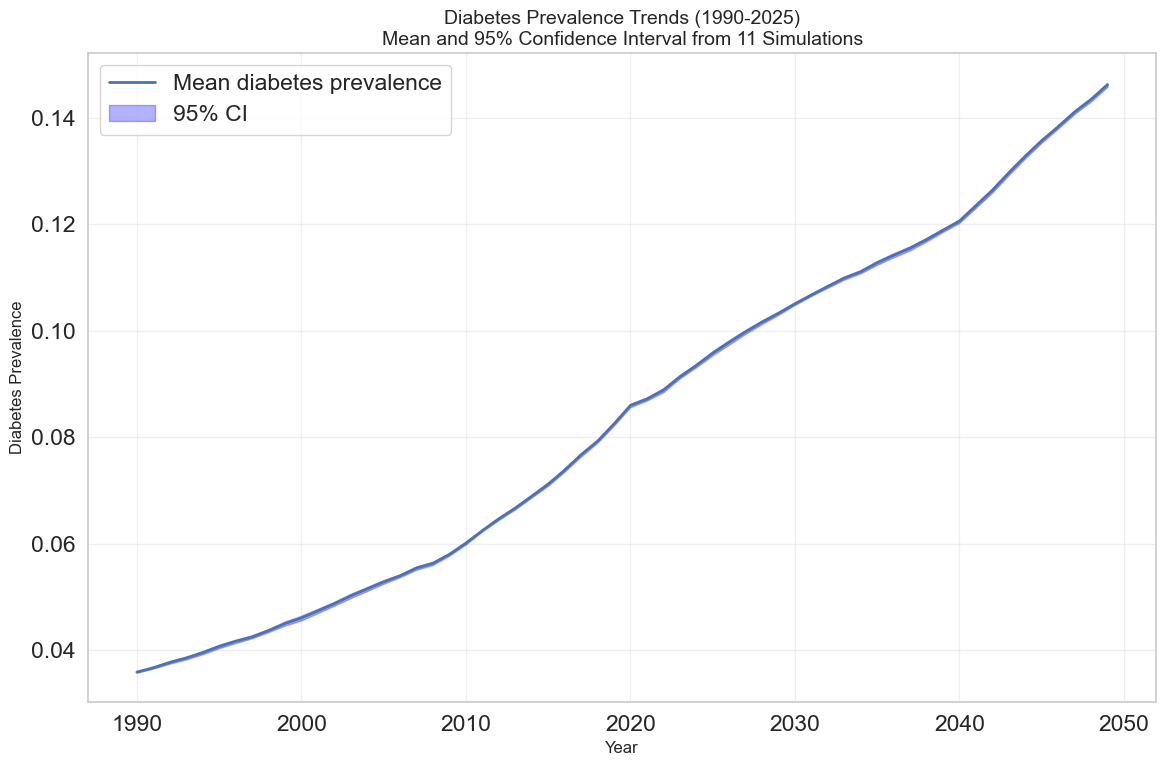

Diabetes prevalence summary (1990-2025):
    year    mean  ci_lower  ci_upper
0   1990  0.0358    0.0357    0.0360
1   1991  0.0367    0.0365    0.0368
2   1992  0.0377    0.0374    0.0379
3   1993  0.0385    0.0382    0.0387
4   1994  0.0395    0.0392    0.0398
5   1995  0.0407    0.0403    0.0410
6   1996  0.0416    0.0413    0.0419
7   1997  0.0425    0.0422    0.0427
8   1998  0.0436    0.0434    0.0439
9   1999  0.0450    0.0446    0.0454
10  2000  0.0460    0.0456    0.0465
11  2001  0.0473    0.0469    0.0478
12  2002  0.0487    0.0483    0.0491
13  2003  0.0502    0.0497    0.0506
14  2004  0.0515    0.0511    0.0519
15  2005  0.0528    0.0524    0.0531
16  2006  0.0539    0.0537    0.0542
17  2007  0.0554    0.0551    0.0557
18  2008  0.0563    0.0560    0.0566
19  2009  0.0580    0.0577    0.0582
20  2010  0.0601    0.0598    0.0603
21  2011  0.0624    0.0623    0.0626
22  2012  0.0646    0.0644    0.0649
23  2013  0.0667    0.0664    0.0669
24  2014  0.0689    0.0686    0.06

In [409]:

# Calculate mean and confidence intervals for plotting
summary_stats = results_df.groupby('year')['diabetes_preva'].agg(['mean', 'std', 'count']).reset_index()
summary_stats['ci_lower'] = summary_stats['mean'] - 1.96 * summary_stats['std'] / np.sqrt(summary_stats['count'])
summary_stats['ci_upper'] = summary_stats['mean'] + 1.96 * summary_stats['std'] / np.sqrt(summary_stats['count'])

# Filter data for 1990-2025 for plotting
plot_data = summary_stats[(summary_stats['year'] >= 1990) & (summary_stats['year'] <= 2049)]

# Create the plot
plt.figure(figsize=(12, 8))
plt.plot(plot_data['year'], plot_data['mean'], 'b-', linewidth=2, label='Mean diabetes prevalence')
plt.fill_between(plot_data['year'], plot_data['ci_lower'], plot_data['ci_upper'], 
                alpha=0.3, color='blue', label='95% CI')

plt.xlabel('Year', fontsize=12)
plt.ylabel('Diabetes Prevalence', fontsize=12)
plt.title('Diabetes Prevalence Trends (1990-2025)\nMean and 95% Confidence Interval from 11 Simulations', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display summary statistics
print("Diabetes prevalence summary (1990-2025):")
print(plot_data[['year', 'mean', 'ci_lower', 'ci_upper']].round(4))
# 0.0890535868891113

In [ ]:
# plot
diabetes_mat_list[]


In [371]:
for i in range(8):
    np.save(f'../future_data_1990_2050/diabetes_matrix/diabetes_mat_{i}.npy', diabetes_mat_list[i])

## hypertension transition (simple version)

In [375]:
hyper_mat_list[0].shape

(11, 93313, 61)

0.36543716266417775

In [377]:
save_dir = "../future_data_1990_2050/hyper_matrix"

import os

# Check if the directory exists and create it if it doesn't
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Created directory: {save_dir}")

# Save the hypertension matrices
for idx, matrix in enumerate(hyper_mat_list):
    file_path = os.path.join(save_dir, f"hyper_mat_{idx}.npy")
    np.save(file_path, matrix)
    print(f"Saved: {file_path}, Shape: {matrix.shape}")



Saved: ../future_data_1990_2050/hyper_matrix/hyper_mat_0.npy, Shape: (11, 93313, 61)
Saved: ../future_data_1990_2050/hyper_matrix/hyper_mat_1.npy, Shape: (11, 98580, 61)
Saved: ../future_data_1990_2050/hyper_matrix/hyper_mat_2.npy, Shape: (11, 27967, 61)
Saved: ../future_data_1990_2050/hyper_matrix/hyper_mat_3.npy, Shape: (11, 28560, 61)
Saved: ../future_data_1990_2050/hyper_matrix/hyper_mat_4.npy, Shape: (11, 16358, 61)
Saved: ../future_data_1990_2050/hyper_matrix/hyper_mat_5.npy, Shape: (11, 14479, 61)
Saved: ../future_data_1990_2050/hyper_matrix/hyper_mat_6.npy, Shape: (11, 5976, 61)
Saved: ../future_data_1990_2050/hyper_matrix/hyper_mat_7.npy, Shape: (11, 6742, 61)


In [378]:
# Load hypertension matrices
hyper_mat_storage = []
save_dir = '../future_data_1990_2050/hyper_matrix'

for idx in range(8):
    file_path = os.path.join(save_dir, f"hyper_mat_{idx}.npy")
    matrix = np.load(file_path)
    hyper_mat_storage.append(matrix)
    print(f"Loaded: {file_path}, Shape: {matrix.shape}")


Loaded: ../future_data_1990_2050/hyper_matrix/hyper_mat_0.npy, Shape: (11, 93313, 61)
Loaded: ../future_data_1990_2050/hyper_matrix/hyper_mat_1.npy, Shape: (11, 98580, 61)
Loaded: ../future_data_1990_2050/hyper_matrix/hyper_mat_2.npy, Shape: (11, 27967, 61)
Loaded: ../future_data_1990_2050/hyper_matrix/hyper_mat_3.npy, Shape: (11, 28560, 61)
Loaded: ../future_data_1990_2050/hyper_matrix/hyper_mat_4.npy, Shape: (11, 16358, 61)
Loaded: ../future_data_1990_2050/hyper_matrix/hyper_mat_5.npy, Shape: (11, 14479, 61)
Loaded: ../future_data_1990_2050/hyper_matrix/hyper_mat_6.npy, Shape: (11, 5976, 61)
Loaded: ../future_data_1990_2050/hyper_matrix/hyper_mat_7.npy, Shape: (11, 6742, 61)


## save the random numbers, this is for intervention 

In [379]:
# Load diabetes matrices
diabetes_mat_list = []
diabetes_save_dir = '../future_data_1990_2050/diabetes_matrix'

for idx in range(8):
    file_path = os.path.join(diabetes_save_dir, f"diabetes_mat_{idx}.npy")
    matrix = np.load(file_path)
    diabetes_mat_list.append(matrix)
    print(f"Loaded diabetes matrix: {file_path}, Shape: {matrix.shape}")

# Load hypertension matrices
hyper_mat_list = []
hyper_save_dir = '../future_data_1990_2050/hyper_matrix'

for idx in range(8):
    file_path = os.path.join(hyper_save_dir, f"hyper_mat_{idx}.npy")
    matrix = np.load(file_path)
    hyper_mat_list.append(matrix)
    print(f"Loaded hypertension matrix: {file_path}, Shape: {matrix.shape}")


Loaded diabetes matrix: ../future_data_1990_2050/diabetes_matrix/diabetes_mat_0.npy, Shape: (11, 93313, 61)
Loaded diabetes matrix: ../future_data_1990_2050/diabetes_matrix/diabetes_mat_1.npy, Shape: (11, 98580, 61)
Loaded diabetes matrix: ../future_data_1990_2050/diabetes_matrix/diabetes_mat_2.npy, Shape: (11, 27967, 61)
Loaded diabetes matrix: ../future_data_1990_2050/diabetes_matrix/diabetes_mat_3.npy, Shape: (11, 28560, 61)
Loaded diabetes matrix: ../future_data_1990_2050/diabetes_matrix/diabetes_mat_4.npy, Shape: (11, 16358, 61)
Loaded diabetes matrix: ../future_data_1990_2050/diabetes_matrix/diabetes_mat_5.npy, Shape: (11, 14479, 61)
Loaded diabetes matrix: ../future_data_1990_2050/diabetes_matrix/diabetes_mat_6.npy, Shape: (11, 5976, 61)
Loaded diabetes matrix: ../future_data_1990_2050/diabetes_matrix/diabetes_mat_7.npy, Shape: (11, 6742, 61)
Loaded hypertension matrix: ../future_data_1990_2050/hyper_matrix/hyper_mat_0.npy, Shape: (11, 93313, 61)
Loaded hypertension matrix: ../f

In [164]:
import pandas as pd

# Read only the first 10 rows (lines 0 to 9) from the Excel file
# ckd/data/mcmc_parameters.xlsx ../data/
 
file_path = '../data/mcmc_parameters.xlsx'
data = pd.read_excel(file_path, nrows=10)

# Extract the relevant coefficients for each ethnicity
ethnicities = ['chn', 'mal', 'ind']
coefficients = {}

for eth in ethnicities:
    # Get the row for the specific ethnicity and convert it to a vector
    coefficients[eth] = data.loc[data['eth'] == eth, ['beta_0', 'beta_1', 'beta_2', 'beta_3', 'beta_4','sigma']].values.flatten()

# Display the coefficients
print(coefficients)
#

{'chn': array([130.84, -0.4671, 14.9112, -0.2066, -5.3749, 13.3742], dtype=object), 'mal': array([121.98, -0.3741, 18.7098, -0.2948, -4.5513, 14.2774], dtype=object), 'ind': array([118.31, -0.3034, 19.8534, -0.3116, -4.6831, 14.4905], dtype=object)}


In [165]:
import numpy as np

coefficients = {
    'chn mal': np.array([130.84 , -0.4671, 14.9112, 0, -5.3749 , 13.3742], dtype=object),
    'chn fem':np.array([130.84, -0.4671, 14.9112, -0.2066, -5.3749, 13.3742], dtype=object),
    'ind mal': np.array([118.31, -0.3034, 19.8534, 0, -4.6831, 14.4905], dtype=object),
    'ind fem': np.array([118.31, -0.3034, 19.8534, 0, -4.6831 , 14.4905], dtype=object),
    'mal mal': np.array([121.98, -0.3741, 18.7098, 0, -4.5513, 14.2774], dtype=object),
    'mal fem': np.array([121.98, -0.3741, 18.7098, -0.2948, -4.5513, 14.2774], dtype=object)
}

print(coefficients)


## use negative

{'chn mal': array([130.84, -0.4671, 14.9112, 0, -5.3749, 13.3742], dtype=object), 'chn fem': array([130.84, -0.4671, 14.9112, -0.2066, -5.3749, 13.3742], dtype=object), 'ind mal': array([118.31, -0.3034, 19.8534, 0, -4.6831, 14.4905], dtype=object), 'ind fem': array([118.31, -0.3034, 19.8534, 0, -4.6831, 14.4905], dtype=object), 'mal mal': array([121.98, -0.3741, 18.7098, 0, -4.5513, 14.2774], dtype=object), 'mal fem': array([121.98, -0.3741, 18.7098, -0.2948, -4.5513, 14.2774], dtype=object)}


In [166]:

def map_eth_str(idx):
    ethnic_keys = ['chn mal','chn fem','mal mal','mal fem','ind mal','ind fem','mal mal','mal fem']  # Mapping indices to dictionary keys
    return ethnic_keys[idx ]

In [ ]:
# Multiply all matrices in albu_mat_storage by 2

if np.max(albu_mat_storage[0]) != 2:
    for i in range(len(albu_mat_storage)):
        albu_mat_storage[i] = albu_mat_storage[i] * 2

In [383]:
np.unique(albu_mat_storage[i])

array([0., 1., 2.])

In [384]:
import numpy as np

eGFR_matrix_ls = []  # List to store eGFR matrices

for idx in range(8):
  # Iterate over the five cases (k=0 to 4)
    case_matrices = []  # Store matrices for this case
    for i, k in enumerate(range(5)):  # k from 0 to 4
        # Extract age matrix for this index
        matrix = age_matrix_vec[idx]  # Contains age values
        bmi_values = bmi_matrix_ls[idx]  # Corresponding BMI values
        albu_value = albu_mat_storage[idx][k, :, :] 
        diabete_value = diabetes_mat_list[idx]
        hyper_value = hyper_mat_list[idx]
        
        eGFR_matrix = np.zeros_like(matrix, dtype=float)
        
        # Get ethnicity and gender
        eth = map_eth_str(idx)  # 'chn', 'ind', or 'mal'
        gender2 = idx % 2  # 0 for Male, 1 for Female

        # Extract coefficients for the ethnicity
        beta0, beta1, beta2, beta3, beta4, sigma = coefficients[eth]
        
        # Generate noise
        row_noise = np.random.normal(loc=0, scale=sigma, size=matrix.shape)
        
        # Compute coefficients based on conditions
        diabetes_coefficient = np.where(diabete_value == 0.5, 0.5, np.where(diabete_value == 1, 1., 0))
        albu_coefficient = np.where(albu_value == 1, 0.1, np.where(albu_value == 2, 0.5, 0))
        hyper_coefficient = 0.1

        # Compute eGFR values
        eGFR_matrix = (
            beta0 +
            beta1 * matrix * 0.5 +  # Age contribution
            beta2 * gender2 +  # Gender contribution
            beta3 * matrix * gender2 * 0.5 +  # Age * Gender interaction
            beta4 * np.log(bmi_values) +  # BMI contribution
            beta1 * matrix * hyper_coefficient * hyper_value + 
            beta1 * matrix * diabetes_coefficient * diabete_value + 
            beta1 * matrix * albu_coefficient * albu_value + 
            row_noise  # Random noise
        )
        
        # Replace invalid age values with -1 in eGFR matrix
        eGFR_matrix[matrix == -1] = -1
        
        case_matrices.append(eGFR_matrix)
    case_matrices = np.array(case_matrices)
    
    eGFR_matrix_ls.append(case_matrices)

# Convert list to a NumPy array for better structure


# Display the resulting eGFR matrix
print("eGFR Matrix:")
print(eGFR_matrix_ls[0][0,:,:])


/var/folders/01/x6yqm8xj77jcsrwqqry44fc40000gq/T/ipykernel_68922/3579664468.py:39: RuntimeWarning: invalid value encountered in log
  beta4 * np.log(bmi_values) +  # BMI contribution


eGFR Matrix:
[[[ -1.          -1.          -1.         ... 104.45343761  98.01406278
   107.05611685]
  [ -1.          -1.          -1.         ... 103.53346367 100.21739165
   104.98006862]
  [ -1.          -1.          -1.         ... 122.47663719 102.20378615
   106.18862351]
  ...
  [ -1.          -1.          -1.         ...  -1.          -1.
    -1.        ]
  [ -1.          -1.          -1.         ...  -1.          -1.
    -1.        ]
  [ -1.          -1.          -1.         ...  -1.          -1.
    -1.        ]]

 [[ -1.          -1.          -1.         ...  97.03424999 109.98346707
   123.15367788]
  [ -1.          -1.          -1.         ...  89.02871273 109.89088755
   120.93900773]
  [ -1.          -1.          -1.         ... 105.05624543  83.30502193
   104.19784837]
  ...
  [ -1.          -1.          -1.         ...  -1.          -1.
    -1.        ]
  [ -1.          -1.          -1.         ...  -1.          -1.
    -1.        ]
  [ -1.          -1.          -1. 

In [229]:
stages = {
    1: lambda x: x > 90,
    2: lambda x: (x >= 60) & (x < 90),
    3.1: lambda x: (x >= 45) & (x < 60),
    3.2: lambda x: (x >= 30) & (x < 45),
    4 : lambda x: (x >= 15) & (x < 30),
    5 : lambda x: (x >= 0) & (x < 15),
    -1 :lambda x: x == -1
}

In [386]:
eGFR_matrix_ls[0].shape

(5, 11, 93313, 61)

In [387]:
# For each matrix, create a corresponding stage matrix (same shape) where each element gets the stage value.
stage_matrix_ls = []
for i in range(8):
    matrix = eGFR_matrix_ls[i]
    # Initialize an output matrix with NaNs
    stage_matrix = np.full(matrix.shape, np.nan)
    # For every stage, update the positions where the condition is True
    for stage, condition in stages.items():
        mask = condition(matrix)
        stage_matrix[mask] = stage
    stage_matrix_ls.append(stage_matrix)

In [388]:
age_matrix_vec[i].shape

(11, 6742, 61)

In [260]:
acr_values

array([1., 0., 0., ..., 0., 0., 0.])

In [389]:

# Initialize lists to store prevalence for each simulation
prevalence_simulations = []

# Iterate through all 5*11=55 simulations
for sim_i in range(5):
    for sim_j in range(11):
        prevalence_yearly = []
        
        # Iterate through each year (columns -61 to -1)
        for year_col in range(-61, 0):
            total_population = 0
            total_ckd_cases = 0

            # Iterate over 8 ethnicity groups
            for i in range(8):
                # Extract age, diabetes, ACR, and stage matrices for this simulation
                ages = age_matrix_vec[i][sim_j,:, year_col]
                acr_values = albu_mat_storage[i][sim_i, sim_j,:, year_col]  # Use k=0 scenario
                stages_col = stage_matrix_ls[i][sim_i, sim_j, :, year_col]  # Use specific simulation

                # Apply age mask
                age_mask = (ages >= 18) & (ages <= 74)

                # Filter variables based on the mask
                filtered_stages = stages_col[age_mask]
                filtered_acr = acr_values[age_mask]

                # Define healthy condition: stage 0 or 1 and ACR = 0
                healthy_mask = (filtered_stages <= 2) & (filtered_acr == 0)

                # Identify non-healthy (CKD) cases
                non_healthy_mask = ~healthy_mask

                # Count total people and CKD cases in this ethnicity group
                total_population += np.sum(age_mask)
                total_ckd_cases += np.sum(non_healthy_mask)

            # Compute overall prevalence for this year
            overall_ckd_prevalence = (total_ckd_cases / total_population) * 100
            prevalence_yearly.append(overall_ckd_prevalence)
        
        # Store the yearly prevalences for this simulation
        prevalence_simulations.append(prevalence_yearly)

# Convert to DataFrame where each row is a simulation and each column is a year
prevalence_df = pd.DataFrame(prevalence_simulations)
prevalence_df.columns = [f'year_{-61+i}' for i in range(61)]  # Years from -61 to -1
prevalence_df.index.name = 'simulation'

# Print result for 2022 (year -28)
year_2022_col = f'year_{-28}'
print(f"2022 CKD Prevalence (Ages 18-74) across simulations:")
print(f"Mean: {prevalence_df[year_2022_col].mean():.2f}%")
print(f"95% CI: ({prevalence_df[year_2022_col].quantile(0.025):.2f}% - {prevalence_df[year_2022_col].quantile(0.975):.2f}%)")



2022 CKD Prevalence (Ages 18-74) across simulations:
Mean: 15.55%
95% CI: (8.56% - 22.30%)


In [396]:
# Initialize lists to store prevalence for each simulation and ethnicity group
prevalence_simulations_all = []
prevalence_simulations_chinese = []
prevalence_simulations_malay = []
prevalence_simulations_indian = []

# Iterate through all 5*11=55 simulations
for sim_i in range(5):
    for sim_j in range(11):
        prevalence_yearly_all = []
        prevalence_yearly_chinese = []
        prevalence_yearly_malay = []
        prevalence_yearly_indian = []
        
        # Iterate through each year (columns -61 to -1)
        for year_col in range(-61, 0):
            # Initialize totals for all ethnicities combined
            total_population_all = 0
            total_ckd_cases_all = 0
            
            # Initialize totals for each ethnicity group
            total_population_chinese = 0
            total_ckd_cases_chinese = 0
            total_population_malay = 0
            total_ckd_cases_malay = 0
            total_population_indian = 0
            total_ckd_cases_indian = 0

            # Iterate over 8 ethnicity groups
            for i in range(8):
                # Extract age, diabetes, ACR, and stage matrices for this simulation
                ages = age_matrix_vec[i][sim_j,:, year_col]
                acr_values = albu_mat_storage[i][sim_i, sim_j,:, year_col]  # Use k=0 scenario
                stages_col = stage_matrix_ls[i][sim_i, sim_j, :, year_col]  # Use specific simulation

                # Apply age mask
                age_mask = (ages >= 18) & (ages <= 74)

                # Filter variables based on the mask
                filtered_stages = stages_col[age_mask]
                filtered_acr = acr_values[age_mask]

                # Define healthy condition: stage 0 or 1 and ACR = 0
                healthy_mask = (filtered_stages <= 2) & (filtered_acr == 0)

                # Identify non-healthy (CKD) cases
                non_healthy_mask = ~healthy_mask

                # Count total people and CKD cases in this ethnicity group
                population_count = np.sum(age_mask)
                ckd_count = np.sum(non_healthy_mask)
                
                # Add to overall totals
                total_population_all += population_count
                total_ckd_cases_all += ckd_count
                
                # Add to specific ethnicity group totals
                if i in [0, 1]:  # Chinese
                    total_population_chinese += population_count
                    total_ckd_cases_chinese += ckd_count
                elif i in [2, 3]:  # Malay
                    total_population_malay += population_count
                    total_ckd_cases_malay += ckd_count
                elif i in [4, 5]:  # Indian
                    total_population_indian += population_count
                    total_ckd_cases_indian += ckd_count

            # Compute overall prevalence for this year
            overall_ckd_prevalence = (total_ckd_cases_all / total_population_all) * 100
            prevalence_yearly_all.append(overall_ckd_prevalence)
            
            # Compute ethnicity-specific prevalences
            chinese_prevalence = (total_ckd_cases_chinese / total_population_chinese) * 100 if total_population_chinese > 0 else 0
            malay_prevalence = (total_ckd_cases_malay / total_population_malay) * 100 if total_population_malay > 0 else 0
            indian_prevalence = (total_ckd_cases_indian / total_population_indian) * 100 if total_population_indian > 0 else 0
            
            prevalence_yearly_chinese.append(chinese_prevalence)
            prevalence_yearly_malay.append(malay_prevalence)
            prevalence_yearly_indian.append(indian_prevalence)
        
        # Store the yearly prevalences for this simulation
        prevalence_simulations_all.append(prevalence_yearly_all)
        prevalence_simulations_chinese.append(prevalence_yearly_chinese)
        prevalence_simulations_malay.append(prevalence_yearly_malay)
        prevalence_simulations_indian.append(prevalence_yearly_indian)

# Convert to DataFrames where each row is a simulation and each column is a year
year_columns = [f'year_{-61+i}' for i in range(61)]  # Years from -61 to -1

prevalence_df_all = pd.DataFrame(prevalence_simulations_all, columns=year_columns)
prevalence_df_chinese = pd.DataFrame(prevalence_simulations_chinese, columns=year_columns)
prevalence_df_malay = pd.DataFrame(prevalence_simulations_malay, columns=year_columns)
prevalence_df_indian = pd.DataFrame(prevalence_simulations_indian, columns=year_columns)

# Add ethnicity identifier
prevalence_df_all['ethnicity'] = 'All'
prevalence_df_chinese['ethnicity'] = 'Chinese'
prevalence_df_malay['ethnicity'] = 'Malay'
prevalence_df_indian['ethnicity'] = 'Indian'

# Combine all dataframes
combined_prevalence_df = pd.concat([
    prevalence_df_all,
    prevalence_df_chinese,
    prevalence_df_malay,
    prevalence_df_indian
], ignore_index=True)

# Print result for 2022 (year -28)
year_2022_col = f'year_{-28}'
print(f"2022 CKD Prevalence (Ages 18-74) across simulations:")
for ethnicity in ['All', 'Chinese', 'Malay', 'Indian']:
    eth_data = combined_prevalence_df[combined_prevalence_df['ethnicity'] == ethnicity][year_2022_col]
    print(f"{ethnicity}: Mean: {eth_data.mean():.2f}%, 95% CI: ({eth_data.quantile(0.025):.2f}% - {eth_data.quantile(0.975):.2f}%)")

# Save the combined dataframe
results_folder = 'results_df'
if not os.path.exists(results_folder):
    os.makedirs(results_folder)

combined_prevalence_df.to_csv(os.path.join(results_folder, 'ckd_prevalence_forecast_by_ethnicity.csv'), index=False)


2022 CKD Prevalence (Ages 18-74) across simulations:
All: Mean: 15.55%, 95% CI: (8.56% - 22.30%)
Chinese: Mean: 15.08%, 95% CI: (8.39% - 21.51%)
Malay: Mean: 19.44%, 95% CI: (10.41% - 28.07%)
Indian: Mean: 15.19%, 95% CI: (8.11% - 21.98%)


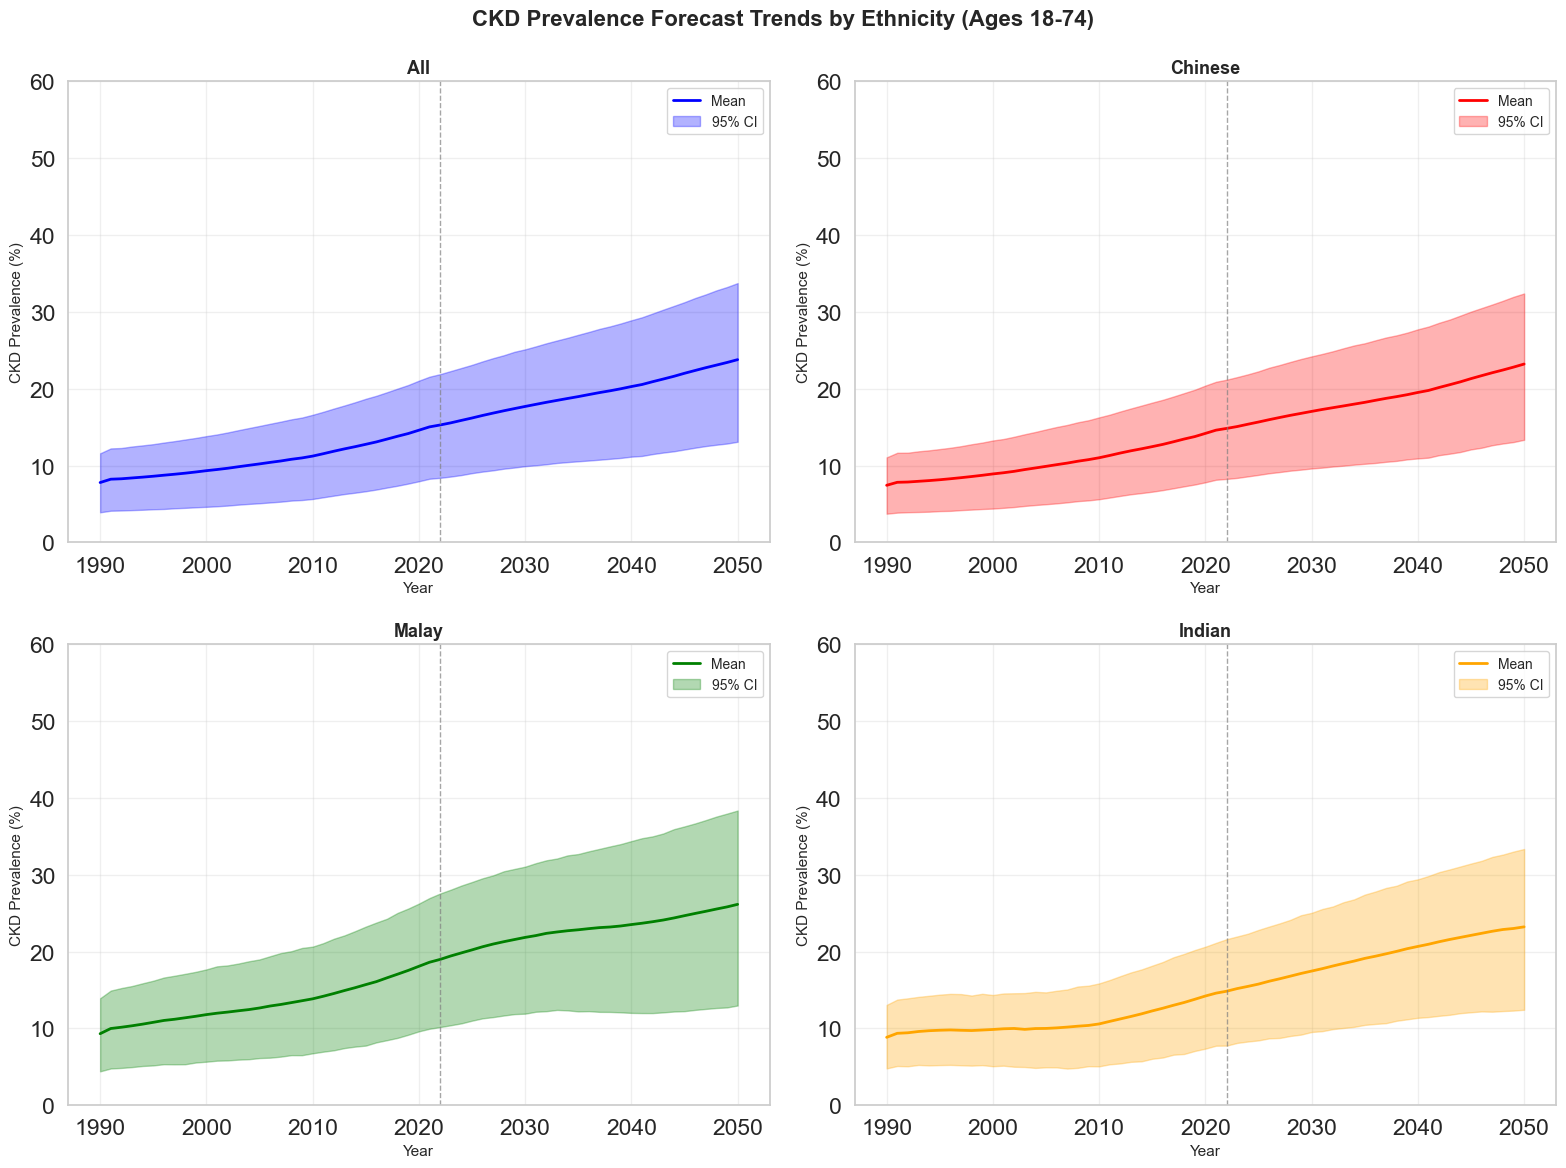


Key Year Statistics by Ethnicity:

All:
  2022: 15.28% (95% CI: 8.39% - 21.89%)
  2050: 23.78% (95% CI: 13.09% - 33.75%)

Chinese:
  2022: 14.83% (95% CI: 8.25% - 21.17%)
  2050: 23.21% (95% CI: 13.35% - 32.40%)

Malay:
  2022: 18.99% (95% CI: 10.18% - 27.57%)
  2050: 26.16% (95% CI: 12.99% - 38.37%)

Indian:
  2022: 14.85% (95% CI: 7.76% - 21.62%)
  2050: 23.23% (95% CI: 12.43% - 33.36%)


In [397]:

# Create panel plot with mean and 95% CI for CKD prevalence trend by ethnicity
import matplotlib.pyplot as plt

# Calculate mean and confidence intervals for each ethnicity
years = range(1990, 2051)  # Years from 1990 to 2050

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('CKD Prevalence Forecast Trends by Ethnicity (Ages 18-74)', fontsize=16, fontweight='bold')

colors = {'All': 'blue', 'Chinese': 'red', 'Malay': 'green', 'Indian': 'orange'}
ethnicities = ['All', 'Chinese', 'Malay', 'Indian']

# Define subplot positions
subplot_positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for idx, ethnicity in enumerate(ethnicities):
    row, col = subplot_positions[idx]
    ax = axes[row, col]
    
    eth_data = combined_prevalence_df[combined_prevalence_df['ethnicity'] == ethnicity]
    year_data = eth_data[year_columns]
    
    mean_prevalence = year_data.mean(axis=0)
    ci_lower = year_data.quantile(0.025, axis=0)
    ci_upper = year_data.quantile(0.975, axis=0)
    
    color = colors[ethnicity]
    ax.plot(years, mean_prevalence, color=color, linewidth=2, label='Mean')
    ax.fill_between(years, ci_lower, ci_upper, alpha=0.3, color=color, label='95% CI')
    
    # Customize each subplot
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('CKD Prevalence (%)', fontsize=11)
    ax.set_title(f'{ethnicity}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 60)
    
    # Add vertical line for 2022
    ax.axvline(x=2022, color='gray', linestyle='--', alpha=0.7, linewidth=1)

plt.tight_layout()

# Save the plot to plots folder
plots_folder = 'plots'
if not os.path.exists(plots_folder):
    os.makedirs(plots_folder)

plt.savefig(os.path.join(plots_folder, 'ckd_prevalence_forecast_panel_by_ethnicity.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics for key years by ethnicity
year_2022_idx = 2022 - 1990  # Index for year 2022
year_2050_idx = 2050 - 1990  # Index for year 2050

print(f"\nKey Year Statistics by Ethnicity:")
for ethnicity in ethnicities:
    eth_data = combined_prevalence_df[combined_prevalence_df['ethnicity'] == ethnicity]
    year_data = eth_data[year_columns]
    
    mean_prevalence = year_data.mean(axis=0)
    ci_lower = year_data.quantile(0.025, axis=0)
    ci_upper = year_data.quantile(0.975, axis=0)
    
    print(f"\n{ethnicity}:")
    print(f"  2022: {mean_prevalence.iloc[year_2022_idx]:.2f}% (95% CI: {ci_lower.iloc[year_2022_idx]:.2f}% - {ci_upper.iloc[year_2022_idx]:.2f}%)")
    print(f"  2050: {mean_prevalence.iloc[year_2050_idx]:.2f}% (95% CI: {ci_lower.iloc[year_2050_idx]:.2f}% - {ci_upper.iloc[year_2050_idx]:.2f}%)")



CKD Prevalence Forecast Results:
             year_-61   year_-60   year_-59   year_-58   year_-57   year_-56  \
simulation                                                                     
0            3.905618   4.109575   4.146119   4.199146   4.197879   4.311765   
1            3.914026   4.193548   4.223140   4.281405   4.307364   4.314589   
2            3.948710   4.185356   4.209136   4.283364   4.370750   4.479340   
3            3.928740   4.155658   4.185130   4.211877   4.296800   4.300468   
4            3.911924   4.084997   4.144119   4.219711   4.227652   4.306116   
5            3.939251   4.200717   4.168125   4.258882   4.276632   4.377665   
6            3.918230   4.140297   4.197133   4.228524   4.313127   4.372017   
7            3.914026   4.135177   4.174127   4.290219   4.275671   4.357895   
8            3.940302   4.117768   4.140118   4.186415   4.256463   4.353188   
9            3.936098   4.126984   4.156122   4.222649   4.318889   4.340008   
10     

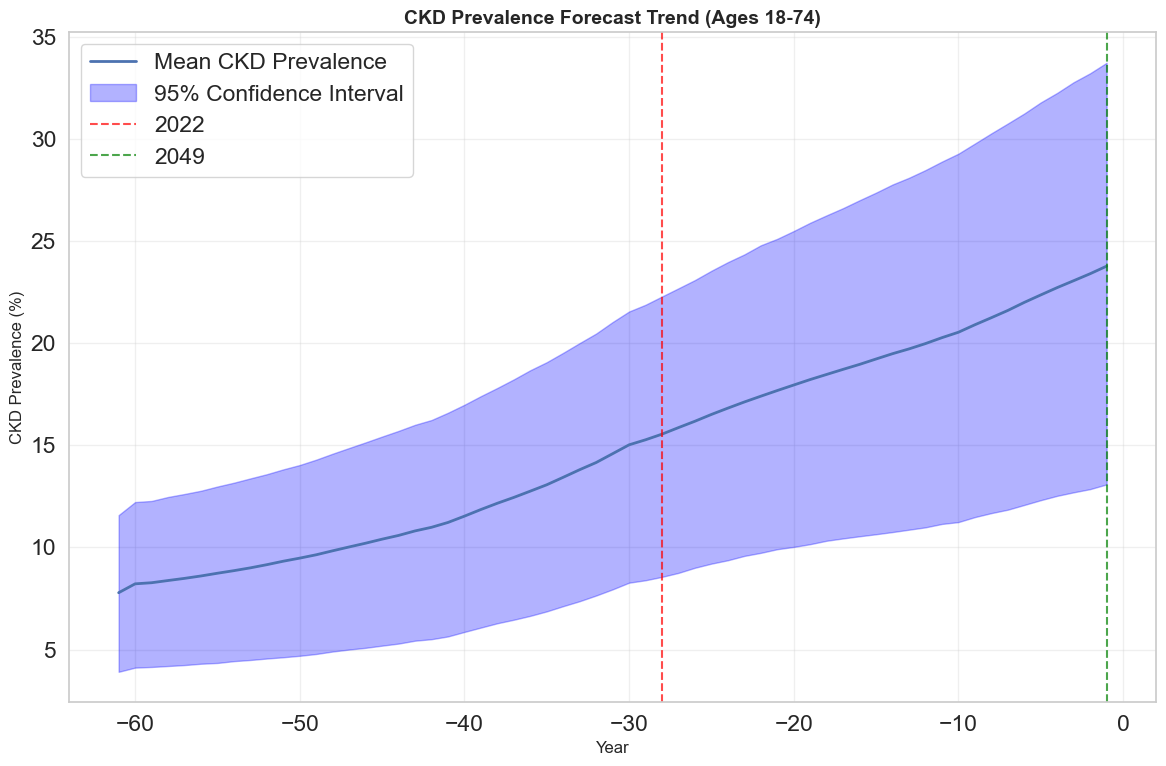


Key Year Statistics:
2022 (year -28): 15.55% (95% CI: 8.56% - 22.30%)
2049 (year -1): 23.78% (95% CI: 13.09% - 33.75%)


In [391]:
# Save prevalence_df to results_df folder
import os

# Create results_df folder if it doesn't exist
results_folder = 'results_df'
if not os.path.exists(results_folder):
    os.makedirs(results_folder)

# Create plots folder if it doesn't exist
plots_folder = 'plots'
if not os.path.exists(plots_folder):
    os.makedirs(plots_folder)

# Save the dataframe
prevalence_df.to_csv(os.path.join(results_folder, 'ckd_prevalence_forecast.csv'))



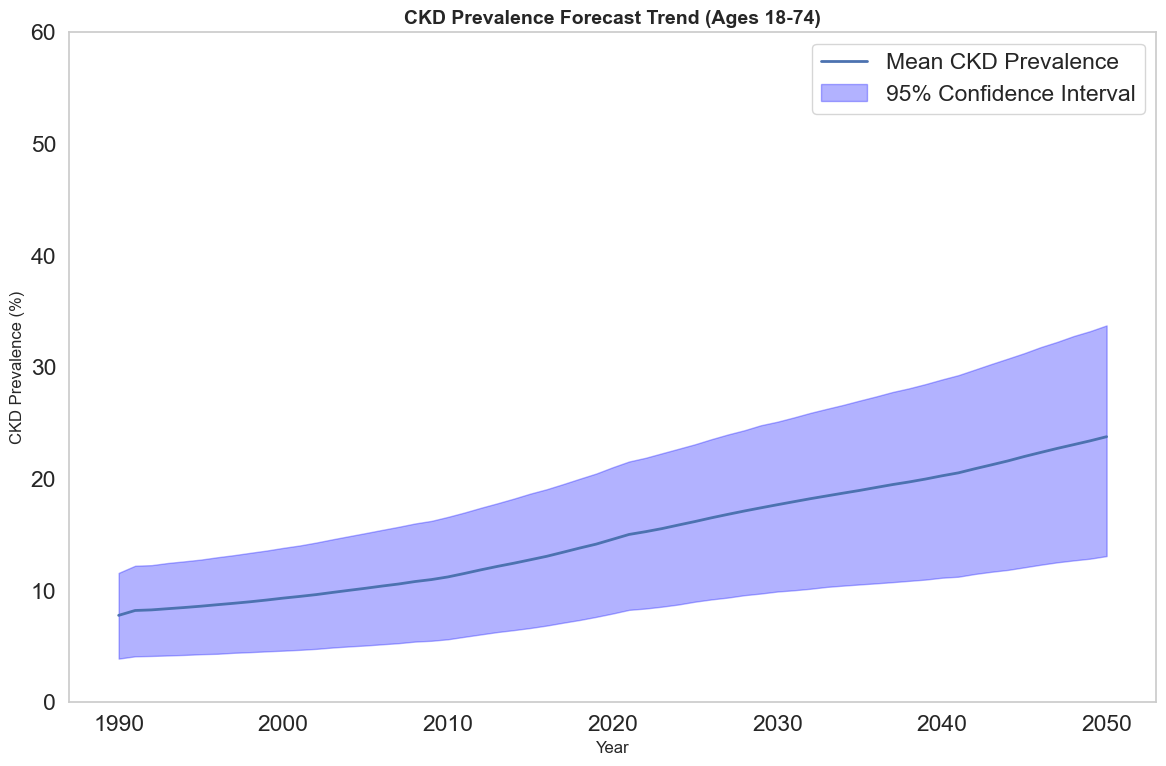


Key Year Statistics:
2022: 15.28% (95% CI: 8.39% - 21.89%)
2050: 23.78% (95% CI: 13.09% - 33.75%)


In [394]:
# Create plot with mean and 95% CI for CKD prevalence trend
import matplotlib.pyplot as plt

# Calculate mean and confidence intervals
years = range(1990, 2051)  # Years from 1990 to 2050
mean_prevalence = prevalence_df.mean(axis=0)
ci_lower = prevalence_df.quantile(0.025, axis=0)
ci_upper = prevalence_df.quantile(0.975, axis=0)

# Create the plot
plt.figure(figsize=(12, 8))
plt.plot(years, mean_prevalence, 'b-', linewidth=2, label='Mean CKD Prevalence')
plt.fill_between(years, ci_lower, ci_upper, alpha=0.3, color='blue', label='95% Confidence Interval')

# Customize the plot
plt.xlabel('Year', fontsize=12)
plt.ylabel('CKD Prevalence (%)', fontsize=12)
plt.title('CKD Prevalence Forecast Trend (Ages 18-74)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(False)
plt.ylim(0, 60)

# Add some key years as reference points
# plt.axvline(x=2022, color='red', linestyle='--', alpha=0.7, label='2022')
# plt.axvline(x=2050, color='green', linestyle='--', alpha=0.7, label='2050')

plt.legend()
plt.tight_layout()

# Save the plot to plots folder
plt.savefig(os.path.join(plots_folder, 'ckd_prevalence_forecast_trend.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics for key years
year_2022_idx = 2022 - 1990  # Index for year 2022
year_2050_idx = 2050 - 1990  # Index for year 2050
print(f"\nKey Year Statistics:")
print(f"2022: {mean_prevalence.iloc[year_2022_idx]:.2f}% (95% CI: {ci_lower.iloc[year_2022_idx]:.2f}% - {ci_upper.iloc[year_2022_idx]:.2f}%)")
print(f"2050: {mean_prevalence.iloc[year_2050_idx]:.2f}% (95% CI: {ci_lower.iloc[year_2050_idx]:.2f}% - {ci_upper.iloc[year_2050_idx]:.2f}%)")


In [205]:
stage_keys = [1, 2, 3.1, 3.2, 4, 5, -1]

# Initialize an 8 x 7 matrix to hold the counts for each of the 8 matrices and 7 stages
stage_counts_mat = np.zeros((8, len(stage_keys)), dtype=int)

# Iterate over the 8 matrices
for i in range(8):
    # Extract the age values from the last column of age_matrix_vec[i]
    ages = age_matrix_vec[i][:, idx]
    # Similarly, extract the corresponding stage values from the last column of stage_matrix_ls[i]
    # (assuming stage values are aligned row-wise)
    stages_col = stage_matrix_ls[i][:, idx]
    
    # Create a mask for entries with age between 18 and 74 (inclusive)
    age_mask = (ages >= 18) & (ages <= 74)
    
    # Apply the mask to the stage values
    filtered_stages = stages_col[age_mask]
    
    # Count how many entries fall into each stage
    counts = [np.sum(filtered_stages == stage) for stage in stage_keys]
    stage_counts_mat[i, :] = counts

In [206]:
col_counts = stage_counts_mat.sum(axis=0)

# Total entries across all stages
total_entries = col_counts.sum()

# Compute percentages for each stage (if total_entries is nonzero)
percentages = (col_counts / total_entries * 100)

In [207]:
percentages

array([7.81477001e+01, 1.97829998e+01, 1.72421204e+00, 3.21754668e-01,
       2.27193182e-02, 6.14035626e-04, 0.00000000e+00])

## beginning map

In [ ]:
nphs_prevalence  = [11.8, 13.8, 20.7, 17.2, 17.6, 11.0]
categories = ['chn mal', 'chn fem', 'mal mal', 'mal fem', 'ind mal', 'ind fem']

2022 CKD Prevalence (Ages 18-74) Summary:
Chinese_Male: Mean: 14.71%, 95% CI: (8.61% - 20.55%)
Chinese_Female: Mean: 15.42%, 95% CI: (8.08% - 22.49%)
Malay_Male: Mean: 21.24%, 95% CI: (11.83% - 30.41%)
Malay_Female: Mean: 17.64%, 95% CI: (8.99% - 25.75%)
Indian_Male: Mean: 18.61%, 95% CI: (10.52% - 26.32%)
Indian_Female: Mean: 11.52%, 95% CI: (5.18% - 17.59%)


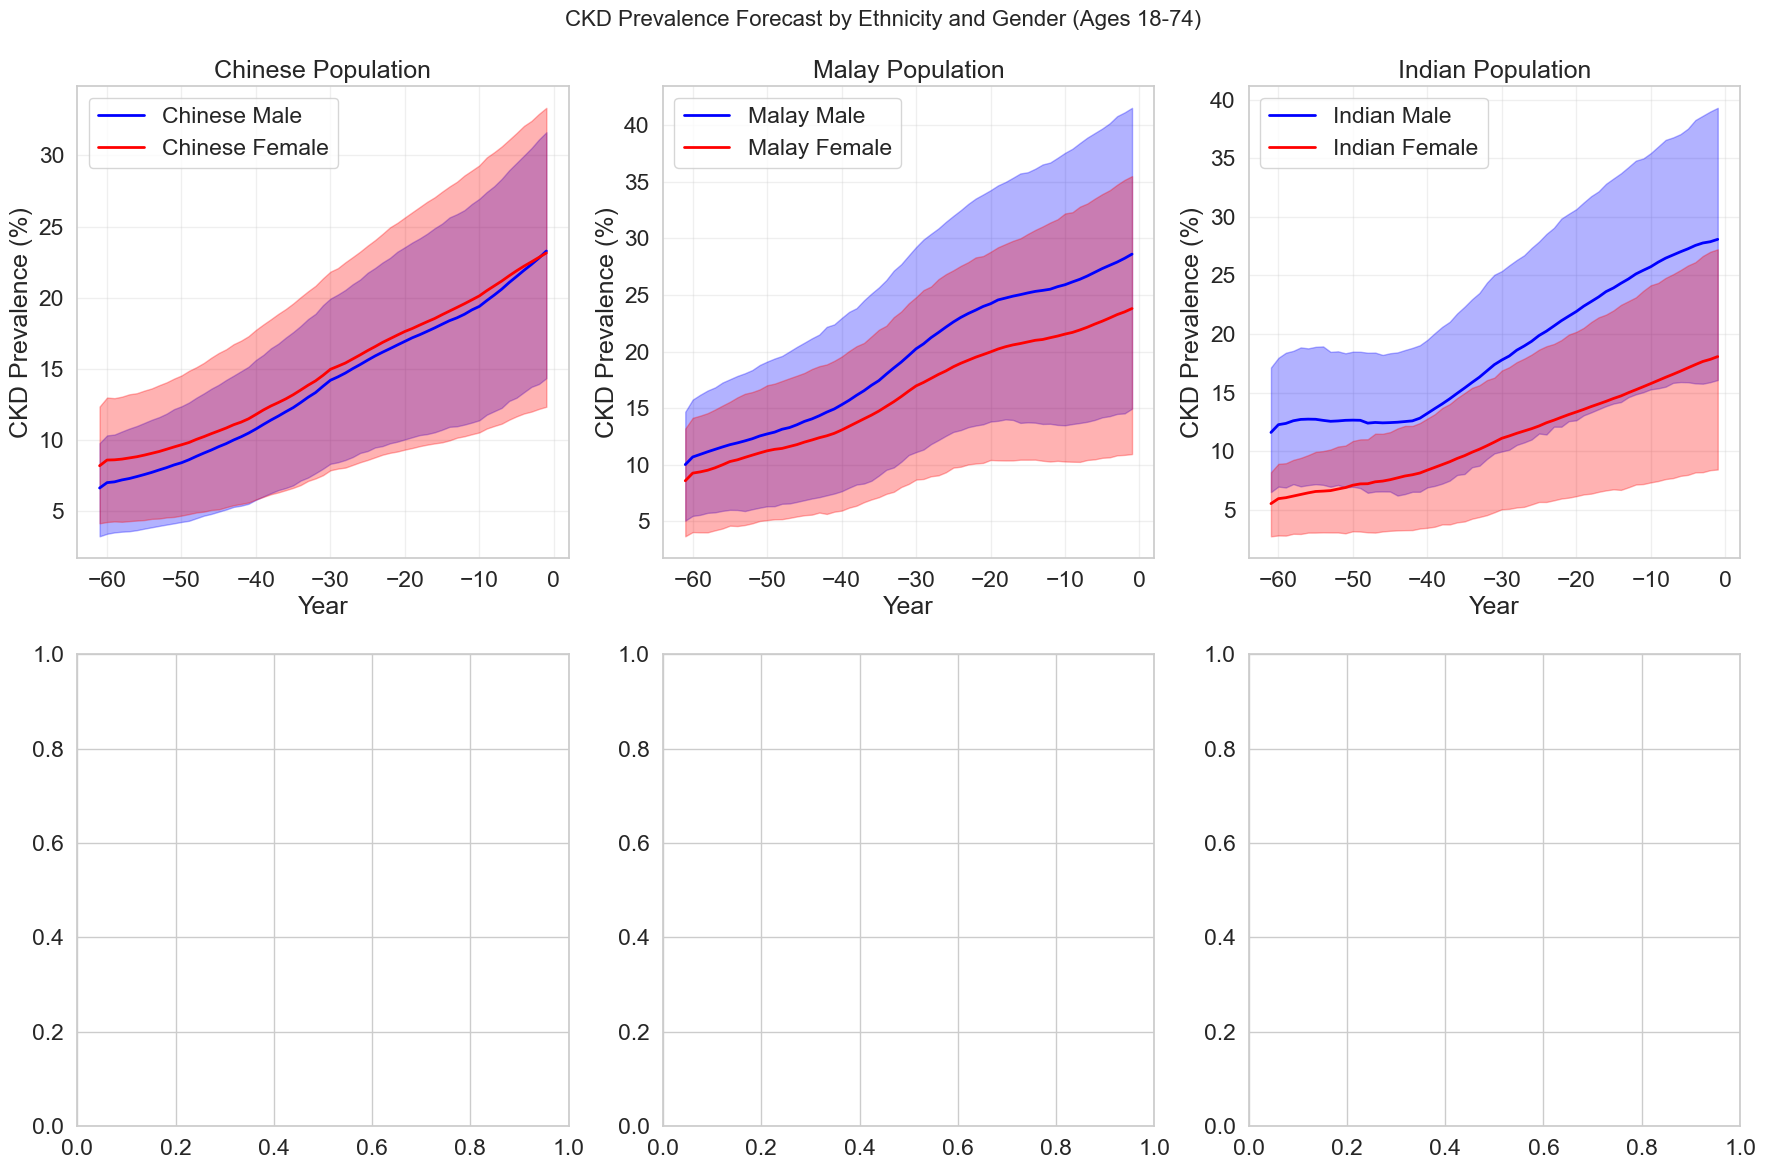


DataFrame shape: (20130, 5)
Unique ethnicities: 6
Unique simulations: 55
Unique years: 61


In [398]:
# Initialize a comprehensive list to store all simulation results
all_simulation_results = []

# Iterate through all 6 ethnicity groups
for i in range(6):  # Changed from 8 to 6 as per instruction
    # Iterate through all 5*11=55 simulations
    for sim_i in range(5):
        for sim_j in range(11):
            prevalence_yearly = []
            
            # Iterate through each year (columns -61 to -1)
            for year_col in range(-61, 0):
                # Extract age, diabetes, ACR, and stage matrices for this simulation
                ages = age_matrix_vec[i][sim_j, :, year_col]
                acr_values = albu_mat_storage[i][sim_i, sim_j, :, year_col]
                stages_col = stage_matrix_ls[i][sim_i, sim_j, :, year_col]

                # Apply age mask (18-74 years)
                age_mask = (ages >= 18) & (ages <= 74)

                # Filter variables based on the mask
                filtered_stages = stages_col[age_mask]
                filtered_acr = acr_values[age_mask]

                # Define healthy condition: stage 0 or 1 and ACR = 0
                healthy_mask = (filtered_stages <= 2) & (filtered_acr == 0)

                # Identify non-healthy (CKD) cases
                non_healthy_mask = ~healthy_mask

                # Count total people and CKD cases
                population_count = np.sum(age_mask)
                ckd_count = np.sum(non_healthy_mask)
                
                # Compute prevalence for this year
                ckd_prevalence = (ckd_count / population_count) * 100 if population_count > 0 else 0
                prevalence_yearly.append(ckd_prevalence)
            
            # Store results for this simulation
            simulation_id = sim_i * 11 + sim_j  # Unique simulation ID from 0 to 54
            
            for year_idx, prevalence in enumerate(prevalence_yearly):
                year_value = -61 + year_idx  # Convert to actual year (-61 to -1)
                all_simulation_results.append({
                    'ethnicity': i,
                    'simulation': simulation_id,
                    'year': year_value,
                    'prevalence': prevalence
                })

# Convert to DataFrame
prevalence_df = pd.DataFrame(all_simulation_results)

# Add ethnicity labels for clarity
ethnicity_labels = {0: 'Chinese_Male', 1: 'Chinese_Female', 2: 'Malay_Male', 
                   3: 'Malay_Female', 4: 'Indian_Male', 5: 'Indian_Female'}
prevalence_df['ethnicity_label'] = prevalence_df['ethnicity'].map(ethnicity_labels)

# Print summary statistics for 2022 (year -28)
print("2022 CKD Prevalence (Ages 18-74) Summary:")
year_2022_data = prevalence_df[prevalence_df['year'] == -28]
for i in range(6):
    eth_data = year_2022_data[year_2022_data['ethnicity'] == i]['prevalence']
    print(f"{ethnicity_labels[i]}: Mean: {eth_data.mean():.2f}%, 95% CI: ({eth_data.quantile(0.025):.2f}% - {eth_data.quantile(0.975):.2f}%)")

# Save the comprehensive dataframe
results_folder = 'results_df'
if not os.path.exists(results_folder):
    os.makedirs(results_folder)

prevalence_df.to_csv(os.path.join(results_folder, 'ckd_prevalence_forecast_comprehensive.csv'), index=False)


# print(f"\nDataFrame shape: {prevalence_df.shape}")
# print(f"Unique ethnicities: {prevalence_df['ethnicity'].nunique()}")
# print(f"Unique simulations: {prevalence_df['simulation'].nunique()}")
# print(f"Unique years: {prevalence_df['year'].nunique()}")


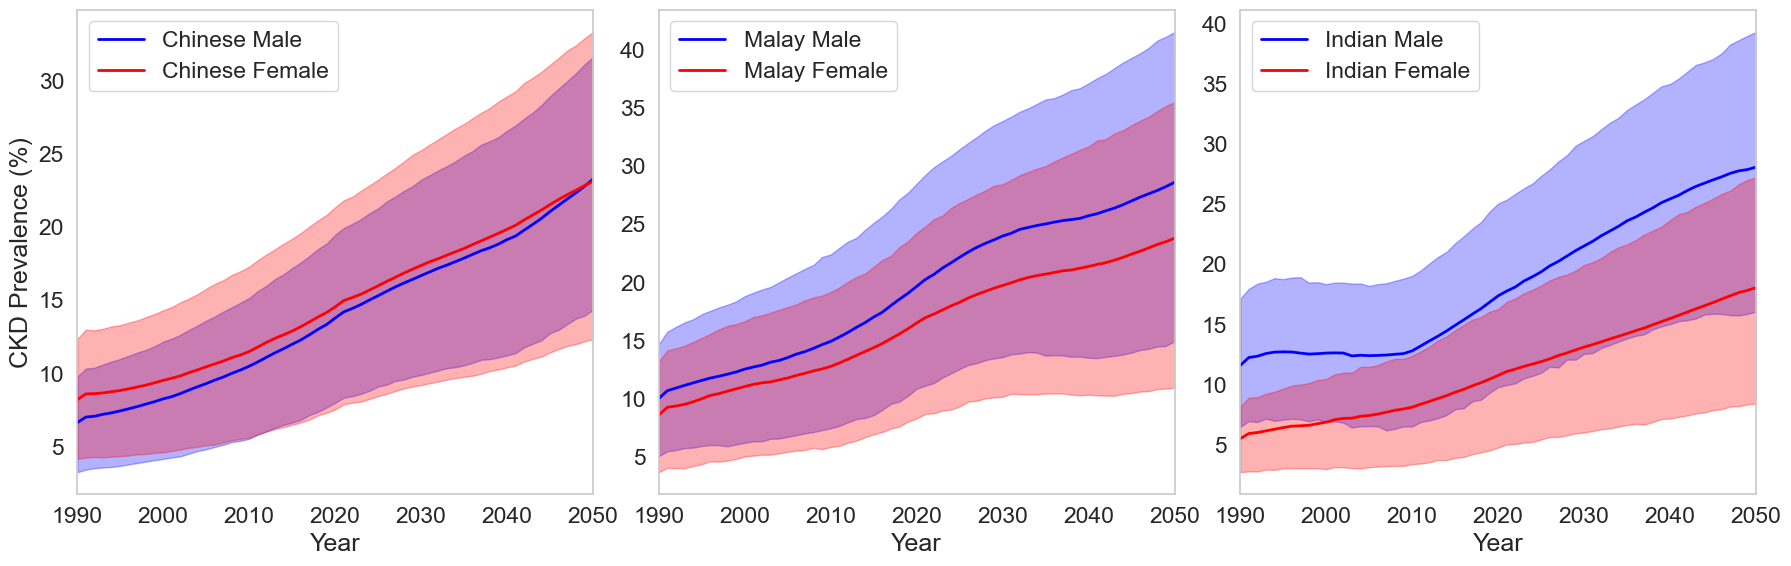

In [399]:
# Create panel plot with 1x3 layout
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Define pairs for plotting
ethnicity_pairs = [(0, 1), (2, 3), (4, 5)]  # (Male, Female) pairs
pair_labels = ['Chinese', 'Malay', 'Indian']

for pair_idx, (male_eth, female_eth) in enumerate(ethnicity_pairs):
    ax = axes[pair_idx]
    
    # Get data for male and female of this ethnicity
    male_data = prevalence_df[prevalence_df['ethnicity'] == male_eth]
    female_data = prevalence_df[prevalence_df['ethnicity'] == female_eth]
    
    # Calculate mean and confidence intervals across simulations for each year
    male_summary = male_data.groupby('year')['prevalence'].agg(['mean', lambda x: x.quantile(0.025), lambda x: x.quantile(0.975)])
    female_summary = female_data.groupby('year')['prevalence'].agg(['mean', lambda x: x.quantile(0.025), lambda x: x.quantile(0.975)])
    
    # Convert years from relative to absolute (year -61 corresponds to 1990, year 0 corresponds to 2051)
    years = male_summary.index + 2051
    
    # Plot mean lines
    ax.plot(years, male_summary['mean'], label=f'{pair_labels[pair_idx]} Male', color='blue', linewidth=2)
    ax.plot(years, female_summary['mean'], label=f'{pair_labels[pair_idx]} Female', color='red', linewidth=2)
    
    # Plot confidence intervals
    ax.fill_between(years, male_summary['<lambda_0>'], male_summary['<lambda_1>'], 
                    alpha=0.3, color='blue')
    ax.fill_between(years, female_summary['<lambda_0>'], female_summary['<lambda_1>'], 
                    alpha=0.3, color='red')
    
    ax.set_xlabel('Year')
    if pair_idx == 0:
        ax.set_ylabel('CKD Prevalence (%)')
    ax.legend()
    ax.grid(False)
    ax.set_xlim(1990, 2050)

plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'ckd_prevalence_panel_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

In [267]:
albu_mat_storage[i]

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 1., 1., 1.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])

In [268]:
np.unique(albu_mat_storage[i])

array([0., 1., 2.])

In [271]:
import numpy as np
import pandas as pd

# Define GFR stages corresponding to the table rows
stage_keys = [1, 2, 3.1, 3.2, 4, 5]  # G1, G2, G3a, G3b, G4, G5

# Define ACR categories corresponding to the table columns
acr_categories = [0, 1, 2]  # Corresponding to A1, A2, A3

# Initialize an empty DataFrame for counts
df_counts = pd.DataFrame(0, index=stage_keys, columns=acr_categories)

# Iterate over the 8 groups
for i in range(8):
    # Extract relevant data
    ages = age_matrix_vec[i][:, idx]   # Age column
    stages_col = stage_matrix_ls[i][:, idx]  # GFR stages
    albu_values = albu_mat_storage[i][-1, :, idx]  # Albumin levels for different thresholds
    
    # Filter ages in range [18, 74]
    age_mask = (ages >= 18) & (ages <= 74)
    
    # Apply the mask to get valid stages
    filtered_stages = stages_col[age_mask]
    filtered_acr = albu_values[age_mask]
    # Iterate over albumin levels (ACR categories: 0,1,2 → A1,A2,A3)
    for acr_idx, acr_level in enumerate(acr_categories):
        # Count occurrences per stage and update df_counts
        for stage in stage_keys:
            count = np.sum((filtered_stages == stage) & (filtered_acr == acr_level))
            df_counts.loc[stage, acr_level] += count

# Rename columns for clarity
df_counts.columns = ['A1', 'A2', 'A3']
df_counts.index = ['G1', 'G2', 'G3a', 'G3b', 'G4', 'G5']

# Display the final table
print(df_counts)



         A1     A2    A3
G1   102675  19619  1850
G2    24413   7223  2483
G3a    1933    825   692
G3b     362    170   388
G4       21     20   134
G5        1      0    42


In [269]:


# Initialize DataFrames for counts
df_counts = pd.DataFrame(0, index=stage_keys, columns=acr_categories)
df_counts_upperbound = pd.DataFrame(0, index=stage_keys, columns=acr_categories)

# Iterate over 8 groups for df_counts
for i in range(8):
    ages = age_matrix_vec[i][:, idx]
    stages_col = stage_matrix_ls[i][:, idx]
    acr_values = albu_mat_storage[i][0, :, idx]  # ACR for base case
    
    age_mask = (ages >= 18) & (ages <= 74)
    
    filtered_stages = stages_col[age_mask]
    filtered_acr = acr_values[age_mask]
    
    for acr_level in acr_categories:
        for stage in stage_keys:
            count = np.sum((filtered_stages == stage) & (filtered_acr == acr_level))
            df_counts.loc[stage, acr_level] += count

# Iterate over 8 groups for df_counts_upperbound
for i in range(8):
    ages = age_matrix_vec[i][:, idx]
    stages_col = stage_matrix_ls[i][:, idx]
    acr_values_upper = albu_mat_storage[i][-1, :, idx]  # ACR for upper bound
    
    age_mask = (ages >= 18) & (ages <= 74)
    
    filtered_stages = stages_col[age_mask]
    filtered_acr = acr_values_upper[age_mask]
    
    for acr_level in acr_categories:
        for stage in stage_keys:
            count = np.sum((filtered_stages == stage) & (filtered_acr == acr_level))
            df_counts_upperbound.loc[stage, acr_level] += count

# Convert counts to percentages using TOTAL sum
df_perc = df_counts / df_counts.values.sum() * 100
df_perc_upperbound = df_counts_upperbound / df_counts_upperbound.values.sum() * 100

# Rename columns for readability
df_counts.columns = df_counts_upperbound.columns = ['A1', 'A2', 'A3']
df_perc.columns = df_perc_upperbound.columns = ['A1', 'A2', 'A3']
df_counts.index = df_counts_upperbound.index = ['G1', 'G2', 'G3a', 'G3b', 'G4', 'G5']
df_perc.index = df_perc_upperbound.index = ['G1', 'G2', 'G3a', 'G3b', 'G4', 'G5']

# Format final table (x1, x2) where x1 from df_counts & df_perc, x2 from df_counts_upperbound & df_perc_upperbound
df_final = df_counts.astype(str) + " (" + df_perc.round(2).astype(str) + "%), " + df_counts_upperbound.astype(str) + " (" + df_perc_upperbound.round(2).astype(str) + "%)"

# Add row and column sums
df_final["Toal"] = df_counts.sum(axis=1).astype(str) + " (" + df_perc.sum(axis=1).round(2).astype(str) + "%), " + df_counts_upperbound.sum(axis=1).astype(str) + " (" + df_perc_upperbound.sum(axis=1).round(2).astype(str) + "%)"
df_final.loc["Total"] = df_counts.sum(axis=0).astype(str) + " (" + df_perc.sum(axis=0).round(2).astype(str) + "%), " + df_counts_upperbound.sum(axis=0).astype(str) + " (" + df_perc_upperbound.sum(axis=0).round(2).astype(str) + "%)"

# Display the final table
print(df_final)


                                     A1                            A2  \
G1     117044 (71.87%), 102675 (63.05%)  6167 (3.79%), 19619 (12.05%)   
G2       30756 (18.89%), 24413 (14.99%)    2901 (1.78%), 7223 (4.44%)   
G3a           2927 (1.8%), 1933 (1.19%)      431 (0.26%), 825 (0.51%)   
G3b            772 (0.47%), 362 (0.22%)       116 (0.07%), 170 (0.1%)   
G4              139 (0.09%), 21 (0.01%)        27 (0.02%), 20 (0.01%)   
G5                 31 (0.02%), 1 (0.0%)          12 (0.01%), 0 (0.0%)   
Total  151669 (93.13%), 129405 (79.46%)  9654 (5.93%), 27857 (17.11%)   

                               A3                              Toal  
G1      933 (0.57%), 1850 (1.14%)  124144 (76.23%), 124144 (76.23%)  
G2      462 (0.28%), 2483 (1.52%)    34119 (20.95%), 34119 (20.95%)  
G3a       92 (0.06%), 692 (0.42%)        3450 (2.12%), 3450 (2.12%)  
G3b       32 (0.02%), 388 (0.24%)          920 (0.56%), 920 (0.56%)  
G4         9 (0.01%), 134 (0.08%)          175 (0.11%), 175 (0.11

In [253]:
# Function to format percentages correctly
def format_percentages(perc_df, perc_upper_df):
    formatted_df = perc_df.copy()
    for row in formatted_df.index:
        for col in formatted_df.columns:
            v1 = round(perc_df.loc[row, col], 2)
            v2 = round(perc_upper_df.loc[row, col], 2)
            formatted_df.loc[row, col] = f"({min(v1, v2)}, {max(v1, v2)})"
    return formatted_df

# Apply formatting function
df_final = format_percentages(df_perc, df_perc_upperbound)

# Add row and column sums
df_final["Row Sum"] = format_percentages(df_perc.sum(axis=1).to_frame(), df_perc_upperbound.sum(axis=1).to_frame()).iloc[:, 0]
df_final.loc["Column Sum"] = format_percentages(df_perc.sum(axis=0).to_frame().T, df_perc_upperbound.sum(axis=0).to_frame().T).iloc[0]

# Display the final table
print(df_final)

                        A1             A2          A3         Row Sum
G1          (62.41, 68.08)    (1.4, 6.79)  (0.0, 0.0)   (69.2, 69.48)
G2          (23.32, 25.36)   (0.68, 2.93)  (0.0, 0.0)  (26.04, 26.25)
G3a           (2.93, 3.21)   (0.09, 0.43)  (0.0, 0.0)    (3.29, 3.36)
G3b           (0.81, 0.87)   (0.05, 0.12)  (0.0, 0.0)    (0.91, 0.92)
G4            (0.19, 0.21)    (0.0, 0.03)  (0.0, 0.0)    (0.22, 0.23)
G5            (0.05, 0.05)    (0.0, 0.01)  (0.0, 0.0)    (0.05, 0.05)
Column Sum  (89.69, 97.78)  (2.22, 10.31)  (0.0, 0.0)             NaN


/var/folders/01/x6yqm8xj77jcsrwqqry44fc40000gq/T/ipykernel_68922/3909463382.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '(62.41, 68.08)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_df.loc[row, col] = f"({min(v1, v2)}, {max(v1, v2)})"
/var/folders/01/x6yqm8xj77jcsrwqqry44fc40000gq/T/ipykernel_68922/3909463382.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '(1.4, 6.79)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_df.loc[row, col] = f"({min(v1, v2)}, {max(v1, v2)})"
/var/folders/01/x6yqm8xj77jcsrwqqry44fc40000gq/T/ipykernel_68922/3909463382.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '(0.0, 0.0)' has dtype incompat

In [172]:
prevalence_df['k0_prevalence']

0      3.912975
1      4.213006
2      4.232143
3      4.298053
4      4.340978
        ...    
56    12.414618
57    12.540026
58    12.624187
59    12.821092
60    13.070091
Name: k0_prevalence, Length: 61, dtype: float64

In [176]:
print(prevalence_df['k0_prevalence'][32])
print(prevalence_df['k1_prevalence'][32])


print(13.8)


8.331106484790105
21.875524345151167
13.8


In [ ]:
# 2022 checking 



In [179]:
idx = 2022 - 2050
idx

-28

In [189]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define ethnicity categories
categories = ['chn mal', 'chn fem', 'mal mal', 'mal fem', 'ind mal', 'ind fem']
nphs_prevalence = [11.8, 13.8, 20.7, 17.2, 17.6, 11.0]  # Target values

# Initialize lists for storing results
ethnicity_ckd_prevalences_low = []
ethnicity_ckd_prevalences_high = []

# Iterate over 6 ethnicity groups
for i in range(6):
    ages = age_matrix_vec[i][:, idx]
    age_mask = (ages >= 18) & (ages <= 74)
    total_population = np.sum(age_mask)

    # Compute CKD prevalence for k-values 0 (low) and 4 (high)
    for  k in [0, -1]:
        acr_values = albu_1_mat_storage[i][k, :, idx]  # ACR for current case
        stages_col = stage_matrix_ls[i][:, idx]

        # Filter variables based on the mask
        filtered_stages = stages_col[age_mask]
        filtered_acr = acr_values[age_mask]

        # Define healthy condition: stage 0 or 1 and ACR = 0
        healthy_mask = (filtered_stages <= 2) & (filtered_acr == 0)

        # Identify CKD cases
        total_ckd_cases = np.sum(~healthy_mask)

        # Compute prevalence
        prevalence = (total_ckd_cases / total_population) * 100 if total_population > 0 else 0

        # Store in appropriate list based on k value
        if k == 0:  # Low prevalence (k=0)
            ethnicity_ckd_prevalences_low.append(prevalence)
        else:  # High prevalence (k=4)
            ethnicity_ckd_prevalences_high.append(prevalence)




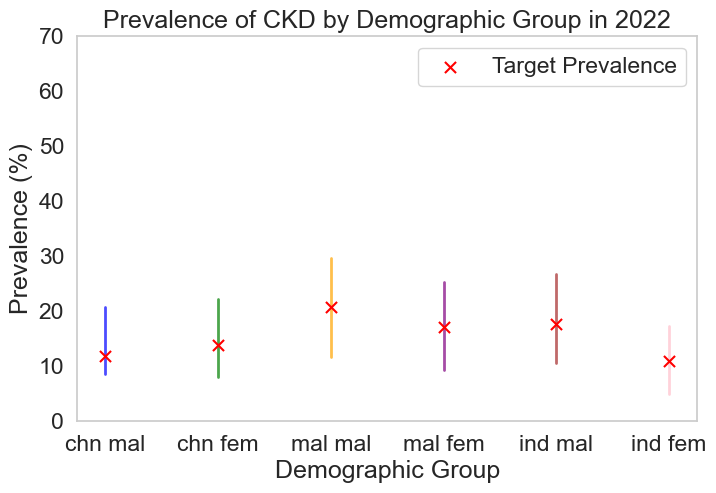

In [202]:
boxplot_data = pd.DataFrame({
    "Demographic Group": ['chn mal', 'chn fem', 'mal mal', 'mal fem', 'ind mal', 'ind fem'],
    "Lower Prevalence": ethnicity_ckd_prevalences_low,
    "Upper Prevalence": ethnicity_ckd_prevalences_high
})

df_melted = boxplot_data.melt(id_vars=["Demographic Group"], 
                              value_vars=["Lower Prevalence", "Upper Prevalence"], 
                              var_name="Bound", value_name="Prevalence")

nphs_prevalence  = [11.8, 13.8, 20.7, 17.2, 17.6, 11.0]
categories = ['chn mal', 'chn fem', 'mal mal', 'mal fem', 'ind mal', 'ind fem']
# Plot
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
# Line plot with vertical lines for CKD prevalence range
x_positions = range(len(categories))
# plt.plot(x_positions, ethnicity_ckd_prevalences_low, 'o-', color='blue', label='Lower Prevalence')
# plt.plot(x_positions, ethnicity_ckd_prevalences_high, 'o-', color='lightblue', label='Upper Prevalence')

# Draw vertical lines connecting lower and upper prevalence for each group
colors = ['blue', 'green', 'orange', 'purple', 'brown', 'pink']
for i, (low, high) in enumerate(zip(ethnicity_ckd_prevalences_low, ethnicity_ckd_prevalences_high)):
    plt.plot([i, i], [low, high], color=colors[i], alpha=0.7, linewidth=2)

plt.xticks(x_positions, categories)

# Overlay the target prevalence as points
plt.scatter(x_positions, nphs_prevalence, color="red", 
           s=64, label="Target Prevalence", zorder=5, marker='x')

plt.grid(False)


# Labels and title
plt.ylim(0, 70)
plt.xlabel("Demographic Group")
plt.ylabel("Prevalence (%)")
plt.title("Prevalence of CKD by Demographic Group in 2022")
plt.legend()

# Show plot
plt.show()

In [185]:
results

[{'Ethnicity': 'chn mal', 'Prevalence (%)': 8.586204534557162},
 {'Ethnicity': 'chn mal', 'Prevalence (%)': 20.78567025138708},
 {'Ethnicity': 'chn fem', 'Prevalence (%)': 7.993768560440095},
 {'Ethnicity': 'chn fem', 'Prevalence (%)': 22.313097382470833},
 {'Ethnicity': 'mal mal', 'Prevalence (%)': 11.690465223399354},
 {'Ethnicity': 'mal mal', 'Prevalence (%)': 29.62690004606172},
 {'Ethnicity': 'mal fem', 'Prevalence (%)': 9.292687419414257},
 {'Ethnicity': 'mal fem', 'Prevalence (%)': 25.299318474857245},
 {'Ethnicity': 'ind mal', 'Prevalence (%)': 10.556548378861374},
 {'Ethnicity': 'ind mal', 'Prevalence (%)': 26.831758999234108},
 {'Ethnicity': 'ind fem', 'Prevalence (%)': 4.960942853227354},
 {'Ethnicity': 'ind fem', 'Prevalence (%)': 17.377004248321228}]

In [192]:
import pandas as pd
import numpy as np

# Define age groups
age_ranges = ["18-39", "40-54", "55-69", "70-74"]

# Initialize lists to store prevalence values
low_prevalence = []
upper_prevalence = []

for a_1, a_2 in [(18, 39), (40, 54), (55, 69), (70, 74)]:
    total_population = 0
    total_ckd_cases = {"low": 0, "upper": 0}
    
    for i in range(8):  # Iterate over 8 ethnicity groups
        ages = age_matrix_vec[i][:, idx]
        stages_col = stage_matrix_ls[i][:, idx]
        age_mask = (ages >= a_1) & (ages <= a_2)
        filtered_stages = stages_col[age_mask]
        
        for label, threshold in zip(["low", "upper"], [0, -1]):
            acr_values = albu_mat_storage[i][threshold, :, idx]
            filtered_acr = acr_values[age_mask]
            healthy_mask = (filtered_stages <= 2) & (filtered_acr == 0)
            non_healthy_mask = ~healthy_mask
            total_ckd_cases[label] += np.sum(non_healthy_mask)
        
        total_population += np.sum(age_mask)
    
    low_prevalence.append((total_ckd_cases["low"] / total_population) * 100)
    upper_prevalence.append((total_ckd_cases["upper"] / total_population) * 100)

# Create DataFrame
target_values = [5, 10, 21, 36]
ckd_prevalence_df = pd.DataFrame({
    "Age Range": age_ranges,
    "Low Prevalence": upper_prevalence,
    "Upper Prevalence": low_prevalence,
    "Target": target_values
})

# Display DataFrame
print(ckd_prevalence_df)



  Age Range  Low Prevalence  Upper Prevalence  Target
0     18-39       16.305530          3.590268       5
1     40-54       17.328904          4.141646      10
2     55-69       29.636573         15.467667      21
3     70-74       44.371192         30.306663      36


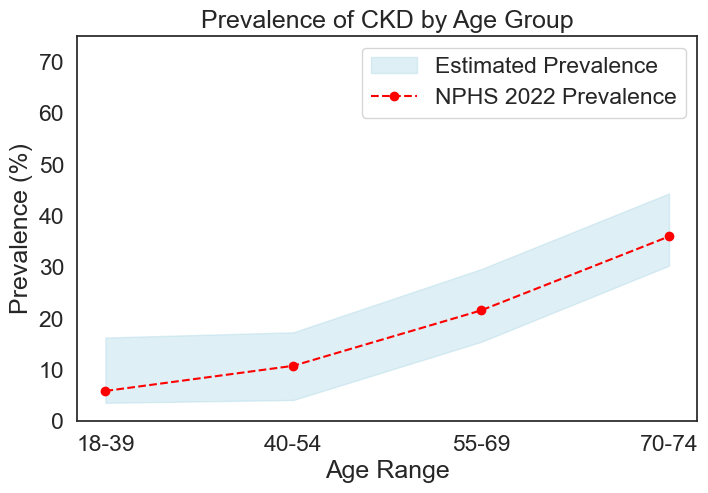

In [193]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data
data = {
    "Age Range": ["18-39", "40-54", "55-69", "70-74"],
    "Low Prevalence": low_prevalence,
    "Upper Prevalence": upper_prevalence,
    "Target": [5.9, 10.8, 21.6, 36]
}
df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(8, 5))
sns.set_style("white")

# Shaded area for prevalence range
plt.fill_between(df["Age Range"], df["Low Prevalence"], df["Upper Prevalence"], color="lightblue", alpha=0.4, label="Estimated Prevalence")

# Line for target prevalence
plt.plot(df["Age Range"], df["Target"], marker="o", linestyle="--", color="red", label="NPHS 2022 Prevalence")
plt.ylim(0,75)
# Labels and title
plt.xlabel("Age Range")
plt.ylabel("Prevalence (%)")
plt.title("Prevalence of CKD by Age Group")
plt.legend()
# Show plot
plt.show()
